In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import gc
#import GeneVocab

## Human MS data

In [2]:
# Human MS data
f = sc.read_h5ad("filtered_ms_adata.h5ad")

In [3]:
sc.pp.log1p(f)
f

AnnData object with n_obs × n_vars = 13468 × 3000
    obs: 'Sample Characteristic[organism]', 'Sample Characteristic Ontology Term[organism]', 'Sample Characteristic[individual]', 'Sample Characteristic Ontology Term[individual]', 'Sample Characteristic[sex]', 'Sample Characteristic Ontology Term[sex]', 'Sample Characteristic[age]', 'Sample Characteristic Ontology Term[age]', 'Sample Characteristic[developmental stage]', 'Sample Characteristic Ontology Term[developmental stage]', 'Sample Characteristic[organism part]', 'Sample Characteristic Ontology Term[organism part]', 'Sample Characteristic[sampling site]', 'Sample Characteristic Ontology Term[sampling site]', 'Sample Characteristic[disease]', 'Sample Characteristic Ontology Term[disease]', 'Sample Characteristic[organism status]', 'Sample Characteristic Ontology Term[organism status]', 'Sample Characteristic[cause of death]', 'Sample Characteristic Ontology Term[cause of death]', 'Sample Characteristic[clinical history]', 'Sample 

### Below is the cell type clustering using the baseline method, scanpy

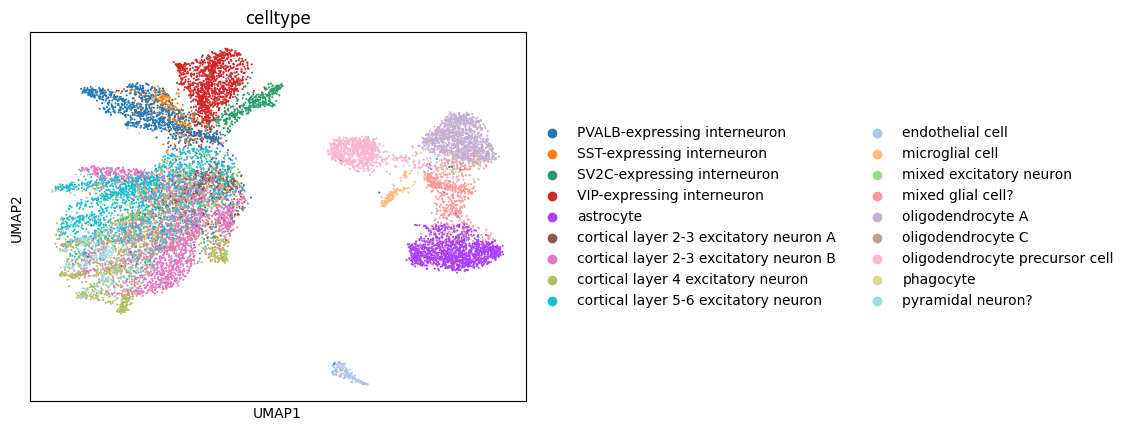

In [4]:
sc.pl.umap(f, color= "celltype", save="original_data_generated_umap.svg")

In [8]:
f2= pd.DataFrame(f.obs["celltype"]).reset_index()
#br_celltype= dict(zip(f2.index, f2["celltype"]))
#br_celltype
print(f2["celltype"].nunique())
f2

18


,index,celltype
0,SRR9123033-AAACCTGAGCTAGCCC,oligodendrocyte A
1,SRR9123033-AAACCTGCAGACGCCT,PVALB-expressing interneuron
2,SRR9123033-AAAGATGGTAGCGTAG,oligodendrocyte A
3,SRR9123033-AAAGATGGTGCCTGGT,oligodendrocyte precursor cell
4,SRR9123033-AAAGTAGCACCAGGTC,oligodendrocyte A
...,...,...
13463,SRR9123052-TTTGGTTCATCCGGGT,cortical layer 5-6 excitatory neuron
13464,SRR9123052-TTTGGTTCATCGATGT,cortical layer 5-6 excitatory neuron
13465,SRR9123052-TTTGGTTGTCAACTGT,VIP-expressing interneuron
13466,SRR9123052-TTTGTCAAGGCTACGA,cortical layer 5-6 excitatory neuron


In [9]:
db= pd.read_csv("E_HCAD_count_matrix.csv")
db_names= db["index"].tolist()
db2= db.merge(f2, on="index", how="left")
db2

,index,CFH,BAD,LAP3,CD99,WNT16,KLHL13,CYP26B1,DBNDD1,SLC7A2,...,DACH1,MARCKS,GPIHBP1,NEFL,IGHG1,GSTT1,TRAC,RP6-191P20.5,RP11-345J4.4,celltype
0,SRR9123033-AAACCTGAGCTAGCCC,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,2.573534,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,oligodendrocyte A
1,SRR9123033-AAACCTGCAGACGCCT,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,2.619293,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,PVALB-expressing interneuron
2,SRR9123033-AAAGATGGTAGCGTAG,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,oligodendrocyte A
3,SRR9123033-AAAGATGGTGCCTGGT,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,2.488792,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,oligodendrocyte precursor cell
4,SRR9123033-AAAGTAGCACCAGGTC,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,2.380725,0.000000,0.0,0.000000,0.0,0.0,0.0,oligodendrocyte A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13463,SRR9123052-TTTGGTTCATCCGGGT,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,1.137901,0.0,1.137901,0.0,0.0,0.0,cortical layer 5-6 excitatory neuron
13464,SRR9123052-TTTGGTTCATCGATGT,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,1.410930,0.0,0.000000,0.0,0.0,0.0,cortical layer 5-6 excitatory neuron
13465,SRR9123052-TTTGGTTGTCAACTGT,1.529693,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,1.430790,0.0,0.000000,0.0,0.0,0.0,VIP-expressing interneuron
13466,SRR9123052-TTTGTCAAGGCTACGA,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,1.488002,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,cortical layer 5-6 excitatory neuron


# Split the count matrix to training, test, and validation dataset

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X= db2.iloc[:, 1:-1]
y= db2.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_valid, y_test, y_valid = train_test_split(X_test, y_test, test_size= 0.3, random_state= 42)

print(X_train.shape, X_test.shape, X_valid.shape, y_train.shape, y_test.shape, y_valid.shape)
print(X.shape)

(9427, 3000) (2828, 3000) (1213, 3000) (9427,) (2828,) (1213,)
(13468, 3000)


# Class for classification

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [6]:
class TransformerClassifier(nn.Module):
    def __init__(self, embedding_dim, num_classes, num_heads=4, num_layers=2, hidden_dim=128):
        super(TransformerClassifier, self).__init__()
        self.embedding = nn.Linear(embedding_dim, hidden_dim)
        encoder_layers = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.fc = nn.Linear(hidden_dim, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.embedding(x)  # Project input to hidden dimension
        x = x.unsqueeze(1)  # Ensure shape is (batch_size, seq_length=1, hidden_dim)
        x = self.transformer_encoder(x)  # Transformer encoder expects (seq_length, batch_size, hidden_dim)
        x = x.squeeze(1)  # Remove extra dimension
        logits = self.fc(x)  # Aggregate features along embedding space
        return self.softmax(logits)


In [7]:
# Training function
def train_classifier(X_train, y_train, X_validation, y_validation, X_test, y_test, embedding_dim, num_classes, epochs=10, lr=0.001, batch_size=32):
    model = TransformerClassifier(embedding_dim, num_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataset = TensorDataset(X_validation, y_validation)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_dataset = TensorDataset(X_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    for epoch in range(epochs):
        model.train()
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
        # Validation step
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                val_loss += criterion(outputs, labels).item()
        
        print(f'Epoch [{epoch+1}/{epochs}], Training Loss: {loss.item():.4f}, Validation Loss: {val_loss / len(val_loader):.4f}')
    
    return model


# Prediction function
def predict(model, X_test):
    with torch.no_grad():
        outputs = model(X_test)
        predicted_labels = torch.argmax(outputs, dim=1)
    return predicted_labels

In [204]:
from sklearn.preprocessing import LabelEncoder
# Initialize LabelEncoder
label_encoder = LabelEncoder()

In [205]:
# Fit on all labels and transform them
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
y_valid_encoded = label_encoder.transform(y_valid)

In [206]:
# Assuming your datasets are in NumPy arrays, convert them to PyTorch tensors
# Convert Pandas Series to NumPy arrays
X_train_tensor = torch.tensor(np.array(X_train), dtype=torch.float32)
X_test_tensor = torch.tensor(np.array(X_test), dtype=torch.float32)
X_valid_tensor = torch.tensor(np.array(X_valid), dtype=torch.float32)

# Convert labels to NumPy arrays with explicit integer conversion
y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)
y_valid_tensor = torch.tensor(y_valid_encoded, dtype=torch.long)

In [207]:
# Define parameters
embedding_dim = 3000  # Based on input shape, i.e., gene number
#num_classes = len(torch.unique(y_train_tensor))  # Automatically infer number of classes
num_classes = 18 # Because we have a total of 18 different cell types in our input data
epochs = 20  # Adjust based on training needs
lr = 0.001
batch_size = 32

# Train the model
model = train_classifier(
    X_train_tensor, y_train_tensor,
    X_valid_tensor, y_valid_tensor,
    X_test_tensor, y_test_tensor,
    embedding_dim, num_classes, 
    epochs=epochs, lr=lr, batch_size=batch_size
)

/home/mccwen/.conda/envs/scFoundation/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch [1/20], Training Loss: 2.4896, Validation Loss: 2.3406
Epoch [2/20], Training Loss: 2.1395, Validation Loss: 2.3397
Epoch [3/20], Training Loss: 2.2433, Validation Loss: 2.3271
Epoch [4/20], Training Loss: 2.4553, Validation Loss: 2.3449
Epoch [5/20], Training Loss: 2.2759, Validation Loss: 2.3176
Epoch [6/20], Training Loss: 2.2973, Validation Loss: 2.3142
Epoch [7/20], Training Loss: 2.4709, Validation Loss: 2.4002
Epoch [8/20], Training Loss: 2.2014, Validation Loss: 2.3219
Epoch [9/20], Training Loss: 2.8643, Validation Loss: 2.6686
Epoch [10/20], Training Loss: 2.5598, Validation Loss: 2.5659
Epoch [11/20], Training Loss: 2.6080, Validation Loss: 2.7470
Epoch [12/20], Training Loss: 2.5831, Validation Loss: 2.5072
Epoch [13/20], Training Loss: 2.0881, Validation Loss: 2.2982
Epoch [14/20], Training Loss: 2.4062, Validation Loss: 2.2394
Epoch [15/20], Training Loss: 2.3490, Validation Loss: 2.2414
Epoch [16/20], Training Loss: 2.2439, Validation Loss: 2.2343
Epoch [17/20], Tr

In [208]:
predicted_labels = predict(model, X_test_tensor)
print("Predicted Labels:", predicted_labels)

Predicted Labels: tensor([4, 4, 0,  ..., 4, 3, 8])


In [4]:
"""
# Compare true cell types with predicted ones for the test data
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_recall_curve, precision_score, recall_score
accuracy =accuracy_score(y_test_tensor, predicted_labels)
print(f"Accuracy: {accuracy}")

conf_matrix = confusion_matrix(y_test_tensor, predicted_labels)
#print(f"Confusion Matrix:\n{conf_matrix}")
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[f'Class {i}' for i in range(18)],
            yticklabels=[f'Class {i}' for i in range(18)], cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for 18 Classes')
plt.xticks(rotation=90)
plt.show()

report= classification_report(y_test_tensor, predicted_labels)
print(f"Classification report: {report}")
"""

'\n# Compare true cell types with predicted ones for the test data\nimport matplotlib.pyplot as plt\nimport seaborn as sns\nfrom sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_recall_curve, precision_score, recall_score\naccuracy =accuracy_score(y_test_tensor, predicted_labels)\nprint(f"Accuracy: {accuracy}")\n\nconf_matrix = confusion_matrix(y_test_tensor, predicted_labels)\n#print(f"Confusion Matrix:\n{conf_matrix}")\nplt.figure(figsize=(12, 10))\nsns.heatmap(conf_matrix, annot=True, fmt=\'d\', cmap=\'Blues\', xticklabels=[f\'Class {i}\' for i in range(18)],\n            yticklabels=[f\'Class {i}\' for i in range(18)], cbar=False)\nplt.xlabel(\'Predicted\')\nplt.ylabel(\'True\')\nplt.title(\'Confusion Matrix for 18 Classes\')\nplt.xticks(rotation=90)\nplt.show()\n\nreport= classification_report(y_test_tensor, predicted_labels)\nprint(f"Classification report: {report}")\n'

In [210]:
# Calculate F1 score for multi-class classification with 'weighted' average
f1 = f1_score(y_test_tensor, predicted_labels, average='macro')
print(f"F1 Score (Macro): {f1}")

# Calculate F1 score for multi-class classification with 'micro' average
f1_micro = f1_score(y_test_tensor, predicted_labels, average='micro')
print(f"F1 Score (Micro): {f1_micro}")

precision_macro = precision_score(y_test_tensor, predicted_labels, average='macro', labels=range(18))
recall_macro = recall_score(y_test_tensor, predicted_labels, average='macro', labels=range(18))
f1_macro = f1_score(y_test_tensor, predicted_labels, average='macro', labels=range(18))
print(f"Test precision: {precision_macro: .3f}")
print(f"Test recall: {recall_macro: .3f}")
print(f"Test F1 score: {f1_macro: .3f}")

F1 Score (Macro): 0.40552954048014667
F1 Score (Micro): 0.754950495049505
Test precision:  0.385
Test recall:  0.439
Test F1 score:  0.406


/home/mccwen/.conda/envs/scFoundation/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [3]:
"""
# Plot F1 score per class
plt.figure(figsize=(10, 6))
plt.bar(range(18), f1_micro )
plt.xticks(range(18), [f'Class {i}' for i in range(18)], rotation=90)
plt.xlabel('Class')
plt.ylabel('F1 Score')
plt.title('F1 (Micro) Score per Class (18 Classes)')
plt.show()
"""

"\n# Plot F1 score per class\nplt.figure(figsize=(10, 6))\nplt.bar(range(18), f1_micro )\nplt.xticks(range(18), [f'Class {i}' for i in range(18)], rotation=90)\nplt.xlabel('Class')\nplt.ylabel('F1 Score')\nplt.title('F1 (Micro) Score per Class (18 Classes)')\nplt.show()\n"

In [213]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Calculate accuracy for each class
accuracy_per_class = []
for i in range(18):  # For each class
    class_mask = (y_test_tensor == i)
    class_accuracy = accuracy_score(y_test_tensor[class_mask], predicted_labels[class_mask])
    accuracy_per_class.append(class_accuracy)


In [2]:
"""
# Plot accuracy per class
plt.figure(figsize=(10, 6))
plt.bar(range(18), accuracy_per_class)
plt.xticks(range(18), [f'Class {i}' for i in range(18)], rotation=90)
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Accuracy per Cell Type (18 Cell Types) on the Test Data')
plt.savefig("gene_exp_based_Accuracy_per_celltype_TestData.png")
plt.show()
"""

'\n# Plot accuracy per class\nplt.figure(figsize=(10, 6))\nplt.bar(range(18), accuracy_per_class)\nplt.xticks(range(18), [f\'Class {i}\' for i in range(18)], rotation=90)\nplt.xlabel(\'Class\')\nplt.ylabel(\'Accuracy\')\nplt.title(\'Accuracy per Cell Type (18 Cell Types) on the Test Data\')\nplt.savefig("gene_exp_based_Accuracy_per_celltype_TestData.png")\nplt.show()\n'

In [215]:
#Compare the true cell types with the predicted ones on validation data
valid_predicted_labels = predict(model, X_valid_tensor)
accuracy =accuracy_score(y_valid_tensor, valid_predicted_labels)
print(f"Accuracy: {accuracy}")

Accuracy: 0.7551525144270403


In [216]:
#conf_matrix = confusion_matrix(y_valid_tensor, valid_predicted_labels)
#print(f"Confusion Matrix:\n{conf_matrix}")

#report= classification_report(y_valid_tensor, valid_predicted_labels)
#print(f"Classification report: {report}")

# Calculate F1 score for multi-class classification with 'weighted' average
f1 = f1_score(y_valid_tensor, valid_predicted_labels, average='macro')
print(f"F1 Score (Macro): {f1}")

# Calculate F1 score for multi-class classification with 'micro' average
f1_micro = f1_score(y_valid_tensor, valid_predicted_labels, average='micro')
print(f"F1 Score (Micro): {f1_micro}")

precision_macro = precision_score(y_valid_tensor, valid_predicted_labels, average='macro', labels=range(18))
recall_macro = recall_score(y_valid_tensor, valid_predicted_labels, average='macro', labels=range(18))
f1_macro = f1_score(y_valid_tensor, valid_predicted_labels, average='macro', labels=range(18))
print(f"Validation precision: {precision_macro: .3f}")
print(f"Validation recall: {recall_macro: .3f}")
print(f"Validation F1 score: {f1_macro: .3f}")

F1 Score (Macro): 0.4058373595620496
F1 Score (Micro): 0.7551525144270403
Validation precision:  0.384
Validation recall:  0.439
Validation F1 score:  0.406


/home/mccwen/.conda/envs/scFoundation/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [217]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Calculate accuracy for each class
accuracy_per_class = []
for i in range(18):  # For each class
    class_mask = (y_valid_tensor == i)
    class_accuracy = accuracy_score(y_valid_tensor[class_mask], valid_predicted_labels[class_mask])
    accuracy_per_class.append(class_accuracy)

In [1]:
"""
# Plot accuracy per class
plt.figure(figsize=(10, 6))
plt.bar(range(18), accuracy_per_class)
plt.xticks(range(18), [f'Class {i}' for i in range(18)], rotation=90)
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Accuracy per Cell Type (18 Cell Types) on the Validation Data')
plt.savefig("gene_exp_Accuracy_per_celltype_ValidData.png")
plt.show()
"""

'\n# Plot accuracy per class\nplt.figure(figsize=(10, 6))\nplt.bar(range(18), accuracy_per_class)\nplt.xticks(range(18), [f\'Class {i}\' for i in range(18)], rotation=90)\nplt.xlabel(\'Class\')\nplt.ylabel(\'Accuracy\')\nplt.title(\'Accuracy per Cell Type (18 Cell Types) on the Validation Data\')\nplt.savefig("gene_exp_Accuracy_per_celltype_ValidData.png")\nplt.show()\n'

# Use scFoundation's embedded data

In [15]:
emb = np.load("ms_emb_01B-resolution_singlecell_cell_embedding_t4_resolution.npy")
len(emb[0])

3072

In [16]:
scf_cell_emb = pd.DataFrame(emb, index=db_names).reset_index()
scf_cell_emb2=scf_cell_emb.merge(f2, on= "index", how= "left")

In [17]:
scf_cell_emb2.iloc[:, 1:-1].isna().any().any() 

np.False_

In [18]:
barcodes= scf_cell_emb2["index"]
adata=sc.AnnData(scf_cell_emb2.iloc[:, 1:-1])
adata.obs['celltype']=pd.Categorical(f2["celltype"])
adata

/home/mccwen/.local/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/mccwen/.local/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 13468 × 3072
    obs: 'celltype'

In [19]:
adata.to_df().isna().any().any()

np.False_

In [20]:
#adata.layers["log_transformed"]= np.log1p(adata.X+1)

#sc.pp.log1p(adata)  # Apply log transformation if required
#sc.pp.scale(adata) 
adata

AnnData object with n_obs × n_vars = 13468 × 3072
    obs: 'celltype'

In [21]:
f2

,index,celltype
0,SRR9123033-AAACCTGAGCTAGCCC,oligodendrocyte A
1,SRR9123033-AAACCTGCAGACGCCT,PVALB-expressing interneuron
2,SRR9123033-AAAGATGGTAGCGTAG,oligodendrocyte A
3,SRR9123033-AAAGATGGTGCCTGGT,oligodendrocyte precursor cell
4,SRR9123033-AAAGTAGCACCAGGTC,oligodendrocyte A
...,...,...
13463,SRR9123052-TTTGGTTCATCCGGGT,cortical layer 5-6 excitatory neuron
13464,SRR9123052-TTTGGTTCATCGATGT,cortical layer 5-6 excitatory neuron
13465,SRR9123052-TTTGGTTGTCAACTGT,VIP-expressing interneuron
13466,SRR9123052-TTTGTCAAGGCTACGA,cortical layer 5-6 excitatory neuron


In [23]:
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.pyplot as plt

In [24]:
scaled_scf_embed_data =StandardScaler().fit_transform(adata.to_df())

In [25]:
embedding = umap.UMAP().fit_transform(scaled_scf_embed_data)
embedding.shape

/home/mccwen/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(13468, 2)

In [26]:
embedding = umap.UMAP().fit(scaled_scf_embed_data)

/home/mccwen/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [27]:
adata.to_df().isna().any().any()
sc.pp.log1p(adata)
adata

/home/mccwen/.local/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:383: RuntimeWarning: invalid value encountered in log1p
  np.log1p(X, out=X)


AnnData object with n_obs × n_vars = 13468 × 3072
    obs: 'celltype'
    uns: 'log1p'

In [28]:
adata.X = np.nan_to_num(adata.X, nan=0)

In [29]:
sc.pp.pca(adata)
sc.pp.neighbors(adata, n_neighbors=18, use_rep='X_pca')
#sc.pp.pca(adata.layers['log_transformed'])
#sc.pp.neighbors(adata.layers['log_transformed'], n_neighbors=18, use_rep='X_pca')  # use_rep='X_pca' if PCA was used

In [30]:
sc.tl.umap(adata) 

In [31]:
adata.obs["celltype"]

0                             oligodendrocyte A
1                  PVALB-expressing interneuron
2                             oligodendrocyte A
3                oligodendrocyte precursor cell
4                             oligodendrocyte A
                          ...                  
13463      cortical layer 5-6 excitatory neuron
13464      cortical layer 5-6 excitatory neuron
13465                VIP-expressing interneuron
13466      cortical layer 5-6 excitatory neuron
13467    cortical layer 2-3 excitatory neuron B
Name: celltype, Length: 13468, dtype: category
Categories (18, object): ['PVALB-expressing interneuron', 'SST-expressing interneuron', 'SV2C-expressing interneuron', 'VIP-expressing interneuron', ..., 'oligodendrocyte C', 'oligodendrocyte precursor cell', 'phagocyte', 'pyramidal neuron?']

In [32]:
adata

AnnData object with n_obs × n_vars = 13468 × 3072
    obs: 'celltype'
    uns: 'log1p', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

## scFoundation embedded data to predict cell type clusters

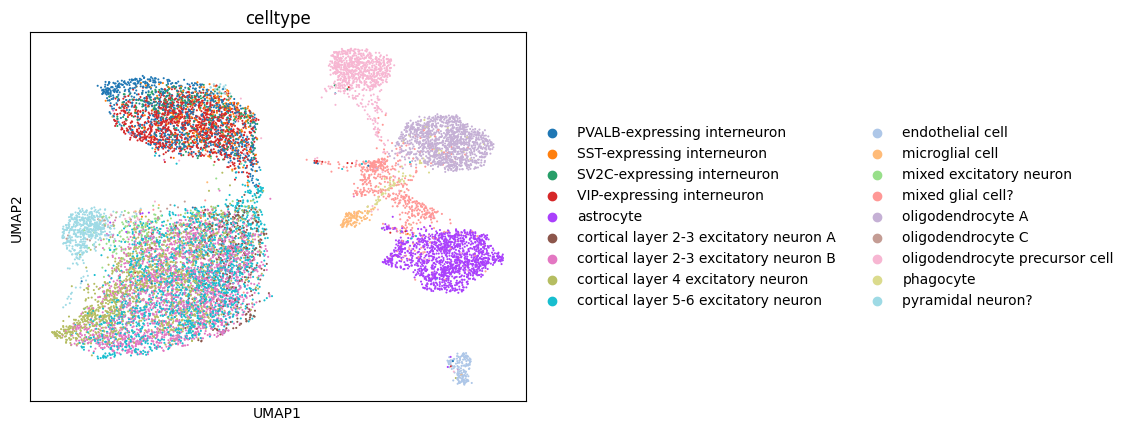

In [33]:
# Cell type umap based oon scf generated embedding space
sc.pl.umap(adata, color=adata.obs, save= "scf_generated_MS_data_embedding_umap.svg")

# Split embedded data into training, testing and validation sets

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X= scf_cell_emb2.iloc[:, 1:-1]
y= scf_cell_emb2.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_valid, y_test, y_valid = train_test_split(X_test, y_test, test_size= 0.3, random_state= 42)

In [36]:
print(X_train.shape, X_test.shape, X_valid.shape, y_train.shape, y_test.shape, y_valid.shape) 

(9427, 3072) (2828, 3072) (1213, 3072) (9427,) (2828,) (1213,)


# Class for classification

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [38]:
class TransformerClassifier(nn.Module):
    def __init__(self, embedding_dim, num_classes, num_heads=4, num_layers=2, hidden_dim=128):
        super(TransformerClassifier, self).__init__()
        self.embedding = nn.Linear(embedding_dim, hidden_dim)
        encoder_layers = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.fc = nn.Linear(hidden_dim, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.embedding(x)  # Project input to hidden dimension
        x = x.unsqueeze(1)  # Ensure shape is (batch_size, seq_length=1, hidden_dim)
        x = self.transformer_encoder(x)  # Transformer encoder expects (seq_length, batch_size, hidden_dim)
        x = x.squeeze(1)  # Remove extra dimension
        logits = self.fc(x)  # Aggregate features along embedding space
        return self.softmax(logits)


# Training function
def train_classifier(X_train, y_train, X_validation, y_validation, X_test, y_test, embedding_dim, num_classes, epochs=10, lr=0.001, batch_size=32):
    model = TransformerClassifier(embedding_dim, num_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataset = TensorDataset(X_validation, y_validation)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_dataset = TensorDataset(X_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    for epoch in range(epochs):
        model.train()
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
        # Validation step
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                val_loss += criterion(outputs, labels).item()
        
        print(f'Epoch [{epoch+1}/{epochs}], Training Loss: {loss.item():.4f}, Validation Loss: {val_loss / len(val_loader):.4f}')
    
    return model

# Prediction function
def predict(model, X_test):
    with torch.no_grad():
        outputs = model(X_test)
        predicted_labels = torch.argmax(outputs, dim=1)
    return predicted_labels


In [39]:
from sklearn.preprocessing import LabelEncoder

In [40]:
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit on all labels and transform them
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
y_valid_encoded = label_encoder.transform(y_valid)

In [41]:
# Assuming your datasets are in NumPy arrays, convert them to PyTorch tensors
# Convert Pandas Series to NumPy arrays
X_train_tensor = torch.tensor(np.array(X_train), dtype=torch.float32)
X_test_tensor = torch.tensor(np.array(X_test), dtype=torch.float32)
X_valid_tensor = torch.tensor(np.array(X_valid), dtype=torch.float32)

# Convert labels to NumPy arrays with explicit integer conversion
y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)
y_valid_tensor = torch.tensor(y_valid_encoded, dtype=torch.long)

In [42]:
# Define parameters
embedding_dim = 3072  # Based on input shape
#num_classes = len(torch.unique(y_train_tensor))  # Automatically infer number of classes
num_classes = 18 # Because we have a total of 18 different cell types in our input data
epochs = 20  # Adjust based on training needs
lr = 0.001
batch_size = 32

# Train the model
model = train_classifier(
    X_train_tensor, y_train_tensor,
    X_valid_tensor, y_valid_tensor,
    X_test_tensor, y_test_tensor,
    embedding_dim, num_classes, 
    epochs=epochs, lr=lr, batch_size=batch_size
)



/home/mccwen/.local/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch [1/20], Training Loss: 2.4565, Validation Loss: 2.4864
Epoch [2/20], Training Loss: 2.4545, Validation Loss: 2.4889
Epoch [3/20], Training Loss: 2.7178, Validation Loss: 2.6456
Epoch [4/20], Training Loss: 2.4020, Validation Loss: 2.4874
Epoch [5/20], Training Loss: 2.6147, Validation Loss: 2.5536
Epoch [6/20], Training Loss: 2.6122, Validation Loss: 2.4764
Epoch [7/20], Training Loss: 2.5169, Validation Loss: 2.4754
Epoch [8/20], Training Loss: 2.4023, Validation Loss: 2.6196
Epoch [9/20], Training Loss: 2.3511, Validation Loss: 2.4794
Epoch [10/20], Training Loss: 2.4541, Validation Loss: 2.4830
Epoch [11/20], Training Loss: 2.5081, Validation Loss: 2.4410
Epoch [12/20], Training Loss: 2.6133, Validation Loss: 2.5165
Epoch [13/20], Training Loss: 2.7710, Validation Loss: 2.8210
Epoch [14/20], Training Loss: 2.8237, Validation Loss: 2.8210
Epoch [15/20], Training Loss: 2.7184, Validation Loss: 2.8210
Epoch [16/20], Training Loss: 2.8237, Validation Loss: 2.8210
Epoch [17/20], Tr

In [43]:
predicted_labels = predict(model, X_test_tensor)
print("Predicted Labels:", predicted_labels)

Predicted Labels: tensor([6, 6, 6,  ..., 6, 6, 6])


# Compare true cell types with predicted ones for the test data

In [45]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_recall_curve, precision_score, recall_score

In [46]:
test_predicted_labels = predict(model, X_test_tensor)
accuracy =accuracy_score(y_test_tensor, test_predicted_labels)
print(f"Test Data Accuracy: {accuracy}")

# Calculate F1 score for multi-class classification with 'weighted' average
f1 = f1_score(y_test_tensor, test_predicted_labels, average='macro')
print(f"Test Data F1 Score (Macro): {f1}")

precision_macro = precision_score(y_test_tensor, test_predicted_labels, average='macro', labels=range(18))
recall_macro = recall_score(y_test_tensor, test_predicted_labels, average='macro', labels=range(18))
f1_macro = f1_score(y_test_tensor, test_predicted_labels, average='macro', labels=range(18))
print(f"Test Data Precision: {precision_macro: .3f}")
print(f"Test Data Recall: {recall_macro: .3f}")
print(f"Test Data F1 Score: {f1_macro: .3f}")

Test Data Accuracy: 0.16831683168316833
Test Data F1 Score (Macro): 0.0160075329566855
Test Data Precision:  0.009
Test Data Recall:  0.056
Test Data F1 Score:  0.016


/home/mccwen/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
"""
# Plot F1 score per class
plt.figure(figsize=(10, 6))
plt.bar(range(18), f1_micro )
plt.xticks(range(18), [f'Class {i}' for i in range(18)], rotation=90)
plt.xlabel('Class')
plt.ylabel('F1 Score')
plt.title('F1 (Micro) Score per Class (18 Classes)')
plt.show()
"""

"\n# Plot F1 score per class\nplt.figure(figsize=(10, 6))\nplt.bar(range(18), f1_micro )\nplt.xticks(range(18), [f'Class {i}' for i in range(18)], rotation=90)\nplt.xlabel('Class')\nplt.ylabel('F1 Score')\nplt.title('F1 (Micro) Score per Class (18 Classes)')\nplt.show()\n"

In [13]:
"""
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Calculate accuracy for each class
accuracy_per_class = []
for i in range(18):  # For each class
    class_mask = (y_test_tensor == i)
    class_accuracy = accuracy_score(y_test_tensor[class_mask], predicted_labels[class_mask])
    accuracy_per_class.append(class_accuracy)

# Plot accuracy per class
plt.figure(figsize=(10, 6))
plt.bar(range(18), accuracy_per_class)
plt.xticks(range(18), [f'Class {i}' for i in range(18)], rotation=90)
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Accuracy per Cell Type (18 Cell Types) on the Test Data')
plt.savefig("scf_embed_Accuracy_per_celltype_TestData.png")
plt.show()
"""

'\nimport matplotlib.pyplot as plt\nfrom sklearn.metrics import accuracy_score\n\n# Calculate accuracy for each class\naccuracy_per_class = []\nfor i in range(18):  # For each class\n    class_mask = (y_test_tensor == i)\n    class_accuracy = accuracy_score(y_test_tensor[class_mask], predicted_labels[class_mask])\n    accuracy_per_class.append(class_accuracy)\n\n# Plot accuracy per class\nplt.figure(figsize=(10, 6))\nplt.bar(range(18), accuracy_per_class)\nplt.xticks(range(18), [f\'Class {i}\' for i in range(18)], rotation=90)\nplt.xlabel(\'Class\')\nplt.ylabel(\'Accuracy\')\nplt.title(\'Accuracy per Cell Type (18 Cell Types) on the Test Data\')\nplt.savefig("scf_embed_Accuracy_per_celltype_TestData.png")\nplt.show()\n'

# Compare the true cell types with the predicted ones on validation data

In [47]:
valid_predicted_labels = predict(model, X_valid_tensor)

In [48]:
accuracy =accuracy_score(y_valid_tensor, valid_predicted_labels)
print(f"Accuracy: {accuracy}")

#conf_matrix = confusion_matrix(y_valid_tensor, valid_predicted_labels)
#print(f"Confusion Matrix:\n{conf_matrix}")

#report= classification_report(y_valid_tensor, valid_predicted_labels)
#print(f"Classification report: {report}")

# Calculate F1 score for multi-class classification with 'weighted' average
f1 = f1_score(y_valid_tensor, valid_predicted_labels, average='macro')
print(f"F1 Score (Macro): {f1}")

# Calculate F1 score for multi-class classification with 'micro' average
f1_micro = f1_score(y_valid_tensor, valid_predicted_labels, average='micro')
print(f"F1 Score (Micro): {f1_micro}")

precision_macro = precision_score(y_valid_tensor, valid_predicted_labels, average='macro', labels=range(18))
recall_macro = recall_score(y_valid_tensor, valid_predicted_labels, average='macro', labels=range(18))
f1_macro = f1_score(y_valid_tensor, valid_predicted_labels, average='macro', labels=range(18))
print(f"Validation precision: {precision_macro: .3f}")
print(f"Validation recall: {recall_macro: .3f}")
print(f"Validation F1 score: {f1_macro: .3f}")

Accuracy: 0.16075845012366036
F1 Score (Macro): 0.015388257575757576
F1 Score (Micro): 0.16075845012366036
Validation precision:  0.009
Validation recall:  0.056
Validation F1 score:  0.015


/home/mccwen/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
"""
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Calculate accuracy for each class
accuracy_per_class = []
for i in range(18):  # For each class
    class_mask = (y_valid_tensor == i)
    class_accuracy = accuracy_score(y_valid_tensor[class_mask], valid_predicted_labels[class_mask])
    accuracy_per_class.append(class_accuracy)


# Plot accuracy per class
plt.figure(figsize=(10, 6))
plt.bar(range(18), accuracy_per_class)
plt.xticks(range(18), [f'Class {i}' for i in range(18)], rotation=90)
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Accuracy per Cell Type (18 Cell Types) on the Validation Data')
plt.savefig("scf_embed_Accuracy_per_celltype_ValidData.png")
plt.show()
"""

'\nimport matplotlib.pyplot as plt\nfrom sklearn.metrics import accuracy_score\n\n# Calculate accuracy for each class\naccuracy_per_class = []\nfor i in range(18):  # For each class\n    class_mask = (y_valid_tensor == i)\n    class_accuracy = accuracy_score(y_valid_tensor[class_mask], valid_predicted_labels[class_mask])\n    accuracy_per_class.append(class_accuracy)\n\n\n# Plot accuracy per class\nplt.figure(figsize=(10, 6))\nplt.bar(range(18), accuracy_per_class)\nplt.xticks(range(18), [f\'Class {i}\' for i in range(18)], rotation=90)\nplt.xlabel(\'Class\')\nplt.ylabel(\'Accuracy\')\nplt.title(\'Accuracy per Cell Type (18 Cell Types) on the Validation Data\')\nplt.savefig("scf_embed_Accuracy_per_celltype_ValidData.png")\nplt.show()\n'